In [444]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from arch import arch_model

import scipy.stats as stats

import utils.Features as util

from dotenv import load_dotenv
import os

import seaborn as sns
sns.set_style(style="whitegrid")

In [445]:
load_dotenv()

START_DATE = os.getenv("START_DATE")
END_DATE = os.getenv("END_DATE")

print(START_DATE, END_DATE)

2008-01-22 2021-12-31


In [446]:
data = pd.read_csv("../Data/dataset/spy_1min_2008_2021_cleaned.csv", index_col=0, parse_dates=True)
data.head()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730


### Realized Volatility Calculation

The code calculates the total daily realized variance by combining intraday variance and overnight variance.

#### 1. Intraday Variance ($RV_{intraday}$)
The intraday variance is calculated using 5-minute returns.
$$
r_{t,i} = \ln\left(\frac{P_{t,i}}{P_{t,i-1}}\right)
$$
where $P_{t,i}$ is the close price at time interval $i$ on day $t$.

The realized intraday variance for day $t$ is the sum of squared 5-minute returns:
$$
RV_{t}^{intraday} = \sum_{i} r_{t,i}^2
$$

#### 2. Overnight Variance ($RV_{overnight}$)
The overnight return captures the gap between the previous day's close and the current day's open.
$$
r_{t}^{overnight} = \ln\left(\frac{P_{t, open}}{P_{t-1, close}}\right)
$$

The overnight variance is the squared overnight return:
$$
RV_{t}^{overnight} = (r_{t}^{overnight})^2
$$

#### 3. Total Realized Variance ($RV_{total}$)
The total daily realized variance is the sum of the intraday and overnight components:
$$
RV_{t}^{total} = RV_{t}^{intraday} + RV_{t}^{overnight}
$$

Finally, the code scales this variance to match GARCH units (multiplying by $100^2$ or $10,000$) and takes the square root to get volatility:
$$
\sigma_{t} = \sqrt{RV_{t}^{total} \times 10000}
$$


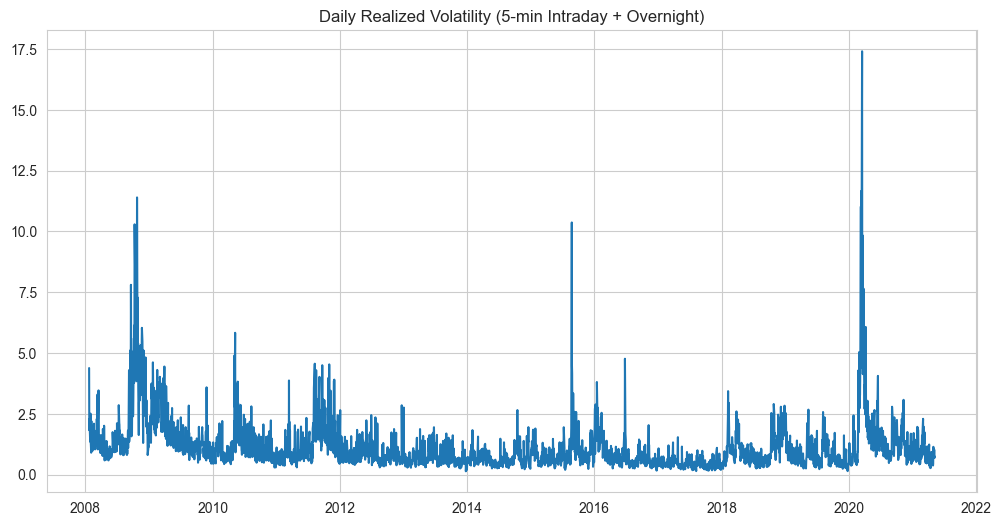

In [468]:
# Intraday Variance
close_5mn = data.close.resample("5min").last().dropna()
rt_intraday = np.log(close_5mn / close_5mn.shift(1)).dropna()
rv_intraday = (rt_intraday ** 2).groupby(rt_intraday.index.date).sum()

# Overnight Variance
daily_ohlc = data.close.resample("1D").agg(['first', 'last']).dropna()
daily_ohlc["prev_close"] = daily_ohlc['last'].shift(1)

# Overnight returns
rt_overnight = np.log(daily_ohlc['first'] / daily_ohlc['prev_close']).dropna()
rv_overnight = rt_overnight ** 2

# Total Realized Variance
rv_total = pd.DataFrame({'intraday': rv_intraday, 'overnight': rv_overnight}).dropna()
rv_total['RV_Daily_Var'] = rv_total['intraday'] + rv_total['overnight']

# Scale to match GARCH (x100^2 = x10000)
target_variance = rv_total['RV_Daily_Var'] * 10000
target_volatility = np.sqrt(target_variance)

target_volatility.head()
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", figsize=(12,6))
plt.show()

In [448]:
ration = .8
split_index = int(len(target_volatility) * ration)
split_date = target_volatility.index[split_index] 
  
print(f"Split date: {split_date}")

Split date: 2018-09-07


In [449]:
diff_volume = data.resample("1D").last().dropna().volume.diff().dropna()
neg_ret = data.resample("1D").last().dropna().close.pct_change().clip(upper=0).dropna()

<Axes: ylabel='Frequency'>

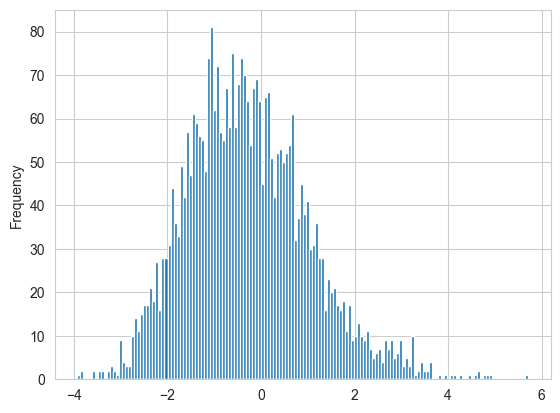

In [450]:
np.log(target_variance).plot(kind='hist', bins=150)

In [451]:
np.log(df_daily.close / df_daily.close.shift(1))

date
2008-01-22         NaN
2008-01-23    0.025098
2008-01-24    0.007215
2008-01-25   -0.013957
2008-01-28    0.016178
                ...   
2021-04-30   -0.006449
2021-05-03    0.002083
2021-05-04   -0.006044
2021-05-05    0.000192
2021-05-06    0.008026
Name: close, Length: 3347, dtype: float64

In [469]:
rv = pd.DataFrame(target_variance)
rv.columns = ["Realized_Variance"]
r = np.log(df_daily.close / df_daily.close.shift(1)).dropna()
rv["Return"] = r[rv.index].values ** 2 * 100
rv["Diff_Vol"] = diff_volume[rv.index].values
rv["Neg_Ret"] = neg_ret[rv.index].values
rv["Log_Var"] = np.log(target_variance[rv.index].values)
rv["Realized_Volatility"] = np.sqrt(target_variance[rv.index].values)
# log_rv = pd.DataFrame(np.log(rv))
# log_rv.columns = ['Log_Realized_Variance']
# diff_rv = pd.DataFrame(rv.diff().dropna())
# diff_rv.columns = ['Realized_Variance_Diff']

In [453]:
import numpy as np
import pandas as pd
from typing import List, Tuple

def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: List[str],
    predict_cols: List[str],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create input-output sequences for time series forecasting.

    Parameters
    ----------
    data : pd.DataFrame
        Time-ordered dataframe.
    lookback : int
        Number of past timesteps used as input.
    horizon : int
        Number of future timesteps to predict.
    feature_cols : list of str
        Columns used as model inputs.
    predict_cols : list of str
        Columns used as prediction targets.

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, lookback, n_features)
    y : np.ndarray
        Shape (n_samples, horizon, n_targets)
    """

    if lookback <= 0 or horizon <= 0:
        raise ValueError("lookback and horizon must be positive integers")

    missing_features = set(feature_cols) - set(data.columns)
    missing_targets = set(predict_cols) - set(data.columns)
    if missing_features or missing_targets:
        raise ValueError(
            f"Missing columns - features: {missing_features}, targets: {missing_targets}"
        )

    values_X = data[feature_cols].values
    values_y = data[predict_cols].values

    X, y = [], []

    max_start = len(data) - lookback - horizon
    for i in range(max_start):
        X.append(values_X[i : i + lookback])
        y.append(values_y[i + lookback : i + lookback + horizon])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [509]:
HORIZON = 1
LOOKBACK = 20
feature_cols = ["Return",]
predict_cols = ["Realized_Variance",]

X_raw, y_raw = create_sequences(
    data=rv,
    lookback=LOOKBACK,
    horizon=HORIZON,
    feature_cols=feature_cols,
    predict_cols=predict_cols,
)


print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

X shape: (3325, 20, 1)  (Samples, Timesteps, Features)
y shape: (3325, 1, 1)  (Samples, Horizon)


In [510]:
ratio = .9
n_sep = int(ratio * X_raw.shape[0])

X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(2992, 20, 1), y=(2992, 1, 1)
Test set: X=(333, 20, 1), y=(333, 1, 1)
Scaled Data:
Training set: X=(2992, 20, 1), y=(2992, 1, 1)
Test set: X=(333, 20, 1), y=(333, 1, 1)


In [511]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (20, 1)
Output size: 1


In [512]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_28 (GRU)                    │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [513]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

In [514]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.6831 - mae: 0.2487 - val_loss: 11.6050 - val_mae: 0.6578 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6409 - mae: 0.2481 - val_loss: 11.1135 - val_mae: 0.6642 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6215 - mae: 0.2379 - val_loss: 10.7537 - val_mae: 0.6724 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.6149 - mae: 0.2409 - val_loss: 11.1343 - val_mae: 0.6719 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6168 - mae: 0.2379 - val_loss: 11.0636 - val_mae: 0.6581 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6138 - mae: 0.2373 - val_loss: 10.9861 - val_mae: 0.6736 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.6169 - mae: 0.2421 - val_loss: 10.8660 - val_mae: 0.6826 - learning_rate: 0.0010
E

In [515]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_test_scaled.shape)

pred_label = "Predicted_Variance"
true_label = "Actual_Variance"

y_pred_df = pd.DataFrame(
    (y_pred)[:, 0], index=rv.index[LOOKBACK + n_sep : -HORIZON], columns=[pred_label]
)
y_true_df = pd.DataFrame(
    (y_true)[:, 0], index=rv.index[LOOKBACK + n_sep : -HORIZON], columns=[true_label]
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


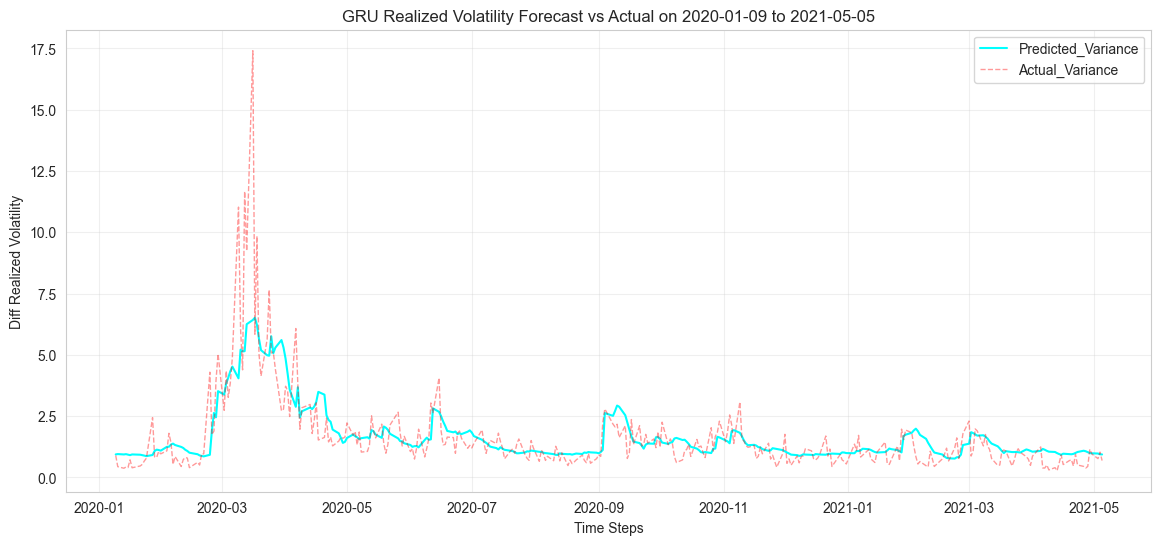

In [516]:
fig, ax = plt.subplots( figsize=(14, 6))
np.sqrt(y_pred_df).plot(ax=ax, color="cyan", legend=True)
np.sqrt(y_true_df).plot(ax=ax, color="red", linewidth=1, linestyle="--", legend=True, alpha=0.4)

plt.title(
    f"GRU Realized Volatility Forecast vs Actual on {y_pred_df.index[0]} to {y_pred_df.index[-1]}"
)
plt.xlabel("Time Steps")
plt.ylabel("Diff Realized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [517]:
def Q_like(pred, true):
    div = true / pred
    ql = div - np.log(div) - 1
    return np.mean(ql)

In [518]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(np.sqrt(y_true_df[1:][true_label]), np.sqrt(y_true_df[true_label]).shift(1).dropna())
naive_mae = mean_absolute_error(np.sqrt(y_true_df[1:][true_label]), np.sqrt(y_true_df[true_label]).shift(1).dropna())
naive_r2 = r2_score(np.sqrt(y_true_df[1:][true_label]), np.sqrt(y_true_df[true_label]).shift(1).dropna())
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline MSE: {naive_mse}")
print(f"Naive Baseline R²: {naive_r2}")
print(f"Naive Q-like: {Q_like(y_true_df[1:][true_label], y_true_df[true_label].shift(1).dropna())}")

print("-" * 40)

mse = mean_squared_error(np.sqrt(y_true_df[true_label]), np.sqrt(y_pred_df[pred_label]))
mae = mean_absolute_error(np.sqrt(y_true_df[true_label]), np.sqrt(y_pred_df[pred_label]))
r2 = r2_score(np.sqrt(y_true_df[true_label]), np.sqrt(y_pred_df[pred_label]))
print(f"Model MAE: {mae}")
print(f"Model MSE: {mse}")
print(f"Model R²: {r2}")
print(f"Model Q-like: {Q_like(y_pred_df[pred_label], y_true_df[true_label])}")

# print("-" * 40)
# print("Absolute differences between Naive Baseline and Model (10 decimal places):")
# print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2020-01-09 to 2021-05-05 Data
Naive Baseline MAE: 0.6332799792289734
Naive Baseline MSE: 1.5879424810409546
Naive Baseline R²: 0.4523216485977173
Naive Q-like: 0.4982549846172333
----------------------------------------
Model MAE: 0.5425733327865601
Model MSE: 1.1208038330078125
Model R²: 0.6124763488769531
Model Q-like: 0.39476245641708374


In [ ]:
# ============================================================
# Evaluating on 2020-01-09 to 2021-05-05 Data
# ============================================================
# Naive Baseline MAE: 0.6332799792289734
# Naive Baseline MSE: 1.5879424810409546
# Naive Baseline R²: 0.4523216485977173
# Naive Q-like: 0.4982549846172333
# ----------------------------------------
# Model MAE: 0.5425733327865601
# Model MSE: 1.1208038330078125
# Model R²: 0.6124763488769531
# Model Q-like: 0.39476245641708374